In [1]:
from torch import nn
import kagglehub
import torch
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torchvision import datasets, transforms
from torchvision.models import alexnet
from torch.nn import functional as F
from torch.optim import Adam, SGD
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import DataLoader, random_split
import seaborn as sns
from PIL import Image
from pathlib import Path
from torch.optim.lr_scheduler import StepLR

/home/var-roman/anaconda3/envs/Analysis_and_processing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset already downloaded
Shape of tensor: torch.Size([32, 3, 227, 227])
Shape of tensor with labels: torch.Size([32])
Example of label: 1


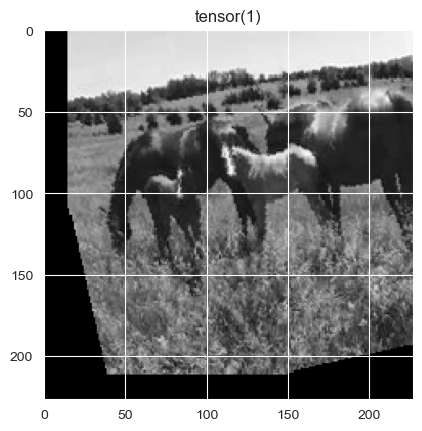

torch.Size([227, 227]) torch.Size([])


In [2]:
# Defining device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not Path('/home/var-roman/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img').exists():
    dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")
else:
    print('Path to dataset already downloaded')
    dataset_path = '/home/var-roman/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img'

IMG_SIZE = 227

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # p=0.5 означає 50% ймовірність
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.RandomHorizontalFlip(p=0.5), # p=0.5 означає 50% ймовірність
    # transforms.RandomRotation(15),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    ])

full_dataset = datasets.ImageFolder(root=dataset_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
generator = torch.Generator()

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)
train_dataset.dataset.transform = train_transforms

BATCH_SIZE = 32
NUM_WORKERS = 4
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS,
                             pin_memory=True)

images, labels = next(iter(train_dataloader))

print(f'Shape of tensor: {images.shape}')
print(f'Shape of tensor with labels: {labels.shape}')
print(f'Example of label: {labels[0]}')
plt.imshow(images[0][0].squeeze(), cmap='gray')
plt.title(labels[0])
plt.show()
print(images[0][0].shape, labels[0].shape)

In [3]:
class_names = ['0 - cane',
               '1 - cavallo',
               '2 - elefante',
               '3 - farfalla',
               '4 - gallina',
               '5 - gatto',
               '6 - mucca',
               '7 - pecora',
               '8 - ragno',
               '9 - scoiattolo']
torch.cuda.is_available()

True

In [4]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

class ModelWithConv2d_Corrected(nn.Module):
    def __init__(self, input_size: int, hidden_units_1: int, hidden_units_2: int, hidden_units_3: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size,
                      out_channels=hidden_units_1,
                      kernel_size=5, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units_1),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=hidden_units_1,
                      out_channels=hidden_units_2,
                      kernel_size=5, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units_2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units_2,
                      out_channels=hidden_units_3,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units_3),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=hidden_units_3,
                      out_channels=hidden_units_3,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units_3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d(output_size=(7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=hidden_units_3 * 7 * 7, out_features=256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=128, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


class OriginalAlexNet(nn.Module):
    def __init__(self, num_classes: int = 10, dropout: float = 0.5) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2))
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # "Вирівнювання" відбувається тут
        x = self.classifier(x)
        return x

num_classes = 10

my_model = ModelWithConv2d_Corrected(input_size=3,
                                     hidden_units_1=16,
                                     hidden_units_2=32,
                                     hidden_units_3=64,
                                     output_shape=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
my_optimizer = Adam(my_model.parameters(), lr=0.0001, weight_decay=1e-4)
my_new_optimizer = SGD(my_model.parameters(), lr=0.001, momentum=0.9, weight_decay = 1e-4)
my_scheduler = StepLR(my_new_optimizer, step_size=5, gamma=0.1)

orig_model = OriginalAlexNet()
orig_model_optim = Adam(orig_model.parameters(), lr=0.0001, weight_decay=1e-4)
orig_new_optim = SGD(orig_model.parameters(), lr=0.0001, momentum=0.9)
orig_scheduler = StepLR(orig_new_optim, step_size=7, gamma=0.1)

In [5]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer:torch.optim.Optimizer) -> (float, torch.Tensor, torch.Tensor):
    loss_count: int = 0

    model.train()
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        train_pred = model(X)
        loss = loss_fn(train_pred, y)
        loss_count += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    loss_count /= len(data_loader)
    # print(f'Train loss: {loss_count:.3f}')
    return loss_count


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    all_preds = []
    all_labels = []
    test_loss = 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            preds = torch.argmax(test_pred, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)
        test_loss /= len(data_loader)

        return test_loss, all_preds, all_labels


def save_model(model: torch.nn.Module, model_name: str):
    model_path = Path("models")
    model_path.mkdir(parents=True,
                     exist_ok=True)

    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name

    print(f"Saving model to: {model_save_path}")
    torch.save(obj=model.state_dict(), f=model_save_path)

def load_model(model: torch.nn.Module, model_name: str) -> torch.nn.Module:
    model_path = Path("models")
    model_full_name = f"{model_name}.pth"
    model_save_path = model_path / model_full_name
    model.load_state_dict(torch.load(f=model_save_path,weights_only=True))
    model = model.to(device)
    return model


def calc_metrics(y_preds, y_true, epochs_train_lt, epochs_test_lt, epochs_num, model_name):
    acc_fn = Accuracy(task="multiclass", num_classes=10)
    accuracy = acc_fn(y_preds, y_true)
    print(f"Загальна точність (Accuracy): {accuracy.item():.4f}")

    conf_matrix_fn = ConfusionMatrix(task="multiclass", num_classes=10)
    prec_fn_macro = Precision(task="multiclass", num_classes=10, average='macro')
    recall_fn_macro = Recall(task="multiclass", num_classes=10, average='macro')
    f1_fn_macro = F1Score(task="multiclass", num_classes=10, average='macro')

    conf_matrix = conf_matrix_fn(y_preds, y_true).numpy()
    precision_macro = prec_fn_macro(y_preds, y_true)
    recall_macro = recall_fn_macro(y_preds, y_true)
    f1_macro = f1_fn_macro(y_preds, y_true)

    print(f"Усереднена прецизійність (Macro Precision): {precision_macro.item():.4f}")
    print(f"Усереднена повнота (Macro Recall): {recall_macro.item():.4f}")
    print(f"Усереднений F1-Score (Macro F1-Score): {f1_macro.item():.4f}")
    fig, ax = plt.subplots(nrows=2, figsize=(12, 10))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax = ax[0]
    )
    ax[0].set_xlabel('Передбачений клас (Predicted Label)')
    ax[0].set_ylabel('Справжній клас (True Label)')
    ax[0].set_title('Матриця помилок (Confusion Matrix)')

    ax[1].plot(range(epochs_num), epochs_train_lt, label="Train loss")
    ax[1].plot(range(epochs_num), epochs_test_lt, label="Test loss")
    ax[1].set_title(f"Модель: {model_name}")
    ax[1].set_ylabel("Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()

def predict_image(model: torch.nn.Module, image_path: str, transform: transforms.Compose, class_names: list):
    try:
        img = Image.open(image_path)
    except FileNotFoundError:
        print(f"Помилка: Не вдалося знайти файл зображення за шляхом {image_path}")
        return None, None
    except Exception as e:
        print(f"Помилка: Не вдалося відкрити зображення {image_path}. {e}")
        return None, None
    model.to(device)
    model.eval()
    try:
        img_transformed = transform(img).unsqueeze(0).to(device)
    except Exception as e:
        print(f"Помилка під час трансформації зображення: {e}")
        return None, None
    with torch.inference_mode():
        pred_logits = model(img_transformed)
        pred_prob = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_prob, dim=1)

    pred_class_name = class_names[pred_label.cpu().item()]
    predicted_probability = pred_prob.max().cpu().item()
    return pred_class_name, predicted_probability

In [22]:
train_time_start_on_gpu = timer()

epochs_train_lt_1 = []
epochs_test_lt_1 = []

epochs = 20
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    epochs_train_lt_1.append(training_step(data_loader=train_dataloader,
                                               model=my_model,
                                               loss_fn=criterion,
                                               optimizer=my_optimizer).cpu().item())
    test_loss_var_1, y_preds_1, y_true_1 = test_step(data_loader=test_dataloader,
                                                 model=my_model,
                                                 loss_fn=criterion)
    epochs_test_lt_1.append(test_loss_var_1.cpu().item())
    # my_scheduler.step()
    print(test_loss_var_1.cpu().item())

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0
---------


  5%|▌         | 1/20 [01:59<37:44, 119.16s/it]

1.6719130277633667
Epoch: 1
---------


 10%|█         | 2/20 [03:55<35:19, 117.77s/it]

...

1.0212855339050293
Epoch: 18
---------


 95%|█████████▌| 19/20 [36:56<01:56, 116.19s/it]

1.01608407497406
Epoch: 19
---------


100%|██████████| 20/20 [38:53<00:00, 116.67s/it]

1.0380432605743408
Train time on cuda: 2333.355 seconds


Загальна точність (Accuracy): 0.6482
Усереднена прецизійність (Macro Precision): 0.6493
Усереднена повнота (Macro Recall): 0.6022
Усереднений F1-Score (Macro F1-Score): 0.6091


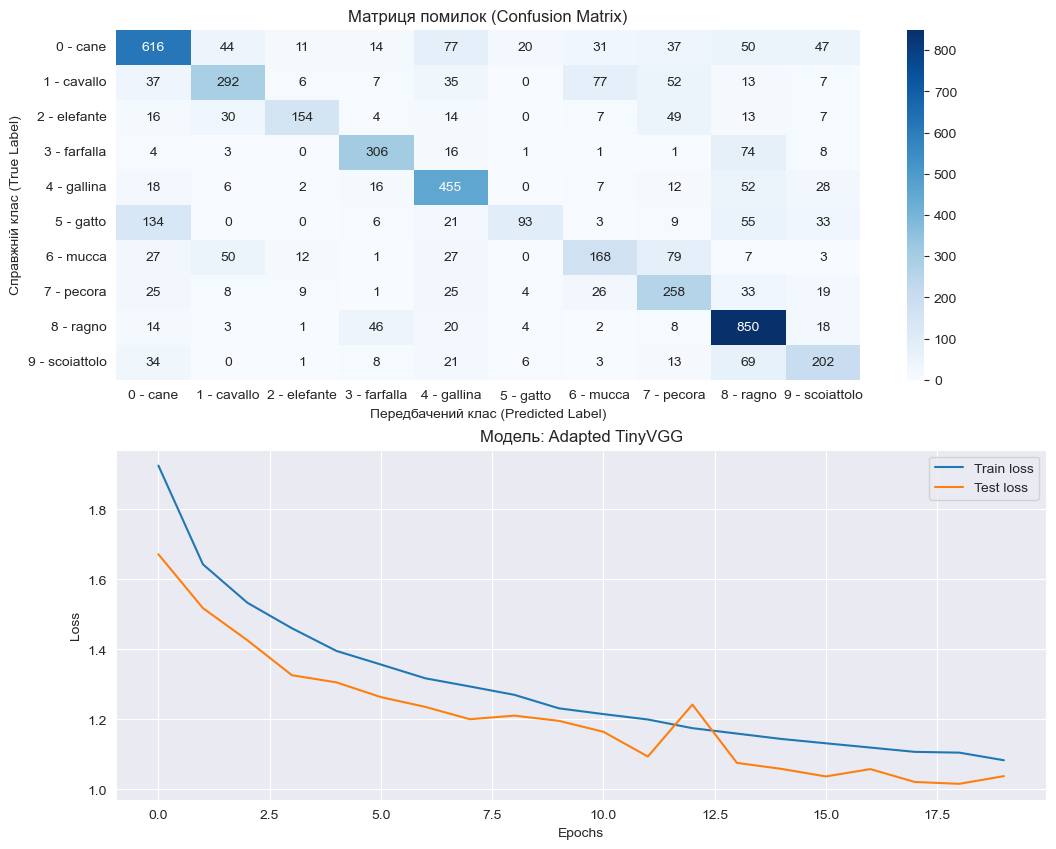

In [23]:
calc_metrics(y_preds_1, y_true_1, epochs_train_lt_1, epochs_test_lt_1, epochs, 'Adapted TinyVGG')

In [24]:
save_model(my_model, 'adapted_tinyVGG_v2_4_16_32_64_Adam')

Saving model to: models/adapted_tinyVGG_v2_4_16_32_64_Adam.pth


In [25]:
train_time_start_on_gpu = timer()

epochs_train_lt_2 = []
epochs_test_lt_2 = []

epochs = 20
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    epochs_train_lt_2.append(training_step(data_loader=train_dataloader,
                                         model=orig_model,
                                         loss_fn=criterion,
                                         optimizer=orig_model_optim).cpu().item())
    test_loss_var_2, y_preds_2, y_true_2 = test_step(data_loader=test_dataloader,
                                                 model=orig_model,
                                                 loss_fn=criterion)
    epochs_test_lt_2.append(test_loss_var_2.cpu().item())
    # orig_scheduler.step()
    print(test_loss_var_2.cpu().item())

train_time_end_on_gpu = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0
---------


  5%|▌         | 1/20 [00:48<15:27, 48.83s/it]

1.7706446647644043
Epoch: 1
---------


 10%|█         | 2/20 [01:37<14:41, 48.99s/it]

...

0.6976307034492493
Epoch: 18
---------


 95%|█████████▌| 19/20 [15:16<00:48, 48.33s/it]

0.6937242746353149
Epoch: 19
---------


100%|██████████| 20/20 [16:04<00:00, 48.20s/it]

0.6838140487670898
Train time on cuda: 964.045 seconds


Загальна точність (Accuracy): 0.7796
Усереднена прецизійність (Macro Precision): 0.7688
Усереднена повнота (Macro Recall): 0.7633
Усереднений F1-Score (Macro F1-Score): 0.7636


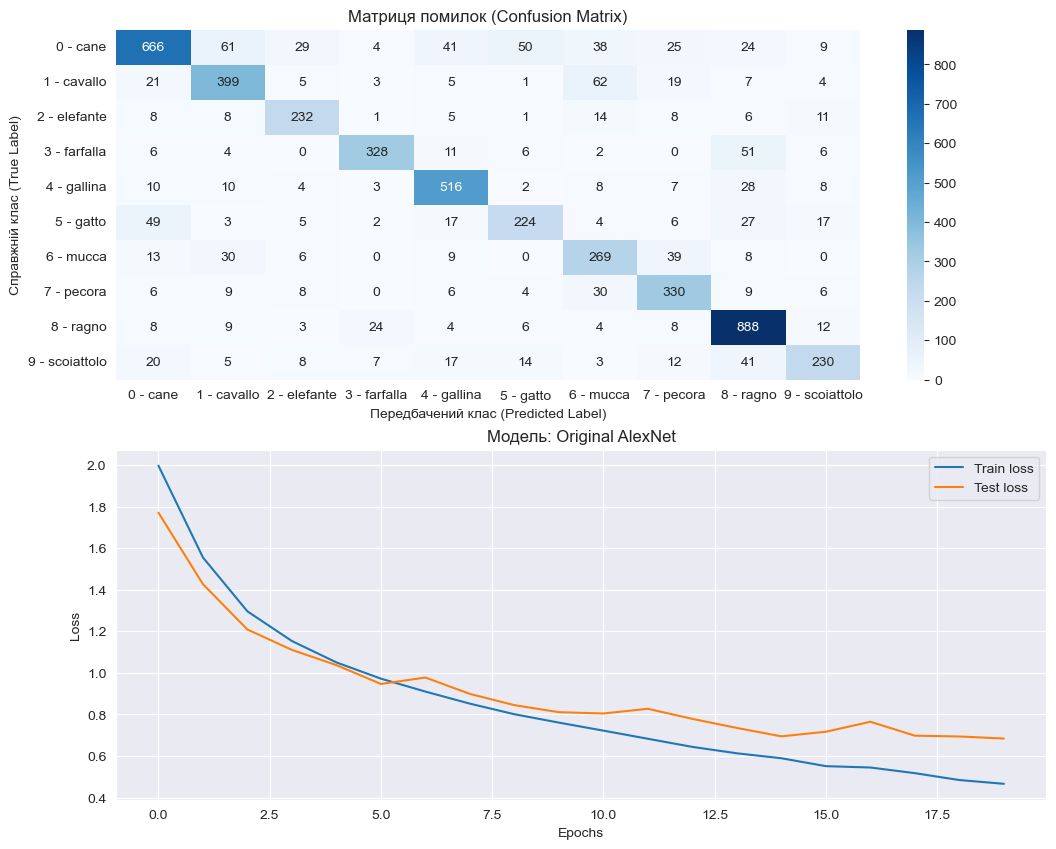

In [26]:
calc_metrics(y_preds_2, y_true_2, epochs_train_lt_2, epochs_test_lt_2, epochs, 'Original AlexNet')

In [27]:
save_model(orig_model, 'orig_AlexNet_10_4_Adam_final')

Saving model to: models/orig_AlexNet_10_4_Adam_final.pth


In [28]:
model_to_eval = load_model(ModelWithConv2d_Corrected(3, 16, 32, 64, 10), 'adapted_tinyVGG_v2_4_16_32_64_SGD')

In [6]:
model_to_eval = load_model(OriginalAlexNet(), 'orig_AlexNet_10_4_Adam_final')

In [30]:
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module):
    loss = 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)

        loss /= len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item()}

In [31]:
res = eval_model(model_to_eval, test_dataloader, criterion)

In [32]:
res

{'model_name': 'OriginalAlexNet', 'model_loss': 0.6707468032836914}

In [7]:
predict_image(model_to_eval, 'my_photo/12-best-hunting-dog-breeds-labrador-retriever.jpeg', test_transforms, class_names=class_names)

('0 - cane', 0.9621714353561401)